### Utility
#### This notebook checks the dataset made from the integration

#### Load the dataset and profile it

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet("../data/training/integrated/algeria_wildfire_dataset.parquet")
df["date"] = pd.to_datetime(df["date"])

print(f"Shape:      {df.shape}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Communes:   {df['commune_id'].nunique()}")
print(f"Wilayas:    {df['wilaya_id'].nunique()}")
print(f"Columns:    {df.columns.tolist()}")

Shape:      (157960, 42)
Date range: 2015-05-01 → 2025-10-30
Communes:   1245
Wilayas:    35
Columns:    ['date', 'commune_id', 'commune_name', 'wilaya_id', 'wilaya_name', 'year', 'month', 'day_of_year', 'day_of_season', 'week_of_year', 'fire_count', 'mean_frp', 'temp_c', 'rh', 'wind_speed_kmh', 'wind_dir', 'precip_mm', 'soil_moisture', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'NDVI', 'NDWI', 'NBR', 'elevation_mean_m', 'slope_mean_deg', 'aspect_mean_deg', 'pop_density_mean', 'road_distance_mean_km', 'forest_fraction', 'shrub_fraction', 'grass_fraction', 'crop_fraction', 'burnable_fraction', 'era5_cell_id', 'next_day_fire_count', 'next_day_frp_sum', 'next_day_risk_class', 'next_day_risk_label']


#### Target/Class distribution

Target distribution (next_day_risk_class):
  0 (LOW     ):  126,368 (80.0%) ████████████████████████████████████████
  1 (MODERATE):   23,670 (15.0%) ███████
  2 (HIGH    ):    7,922 (5.0%) ██


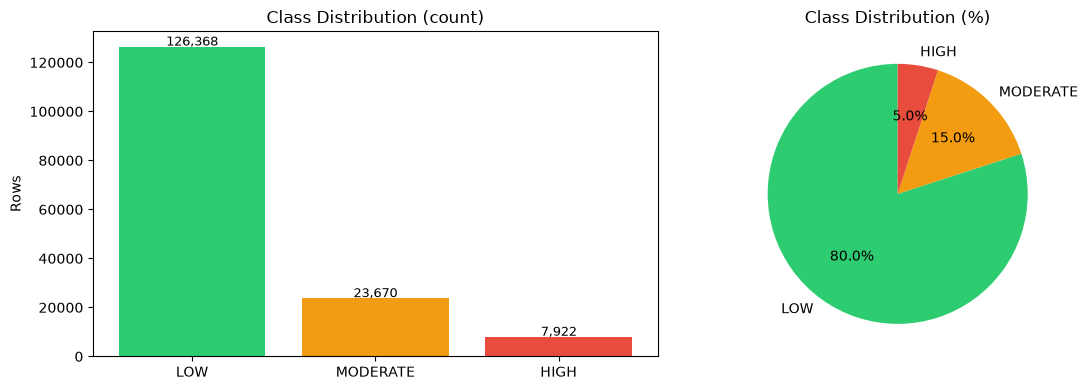

In [2]:
RISK_LABELS = {0: "LOW", 1: "MODERATE", 2: "HIGH"}

dist = df["next_day_risk_class"].value_counts().sort_index()
total = len(df)

print("Target distribution (next_day_risk_class):")
for cls, count in dist.items():
    pct = 100 * count / total
    bar = "█" * int(pct / 2)
    print(f"  {cls} ({RISK_LABELS[cls]:<8}): {count:>8,} ({pct:.1f}%) {bar}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(
    [RISK_LABELS[i] for i in dist.index],
    dist.values,
    color=["#2ecc71", "#f39c12", "#e74c3c"]
)
axes[0].set_title("Class Distribution (count)")
axes[0].set_ylabel("Rows")
for i, v in enumerate(dist.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=9)

# Pie
axes[1].pie(
    dist.values,
    labels=[RISK_LABELS[i] for i in dist.index],
    colors=["#2ecc71", "#f39c12", "#e74c3c"],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Class Distribution (%)")

plt.tight_layout()
plt.savefig("outputs/01_target_distribution.png", dpi=150)
plt.show()

#### Missing value validation

In [3]:
missing = df.isnull().sum()
missing_pct = 100 * missing / len(df)
missing_df = pd.DataFrame({
    "count": missing,
    "pct": missing_pct
}).query("count > 0").sort_values("pct", ascending=False)

if len(missing_df) == 0:
    print("No missing values")
else:
    print(f" {len(missing_df)} columns with missing values:\n")
    print(missing_df.to_string())

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(missing_df.index, missing_df["pct"], color="#e74c3c")
    ax.set_xlabel("Missing %")
    ax.set_title("Missing Values by Column")
    for i, (col, row) in enumerate(missing_df.iterrows()):
        ax.text(row["pct"] + 0.1, i, f"{row['pct']:.1f}%", va="center")
    plt.tight_layout()
    plt.savefig("outputs/01_missing_values.png", dpi=150)
    plt.show()

No missing values


#### temporal coverage

Temporal coverage by year:
 year  rows  fire_days  communes positive_rate
 2015 13767       2222      1245         16.1%
 2016 14308       2971      1245         20.8%
 2017 14852       3368      1245         22.7%
 2018 13836       2245      1245         16.2%
 2019 15717       4423      1245         28.1%
 2020 16899       5593      1245         33.1%
 2021 14244       2754      1245         19.3%
 2022 14169       2665      1245         18.8%
 2023 13598       1963      1245         14.4%
 2024 13072       1326      1245         10.1%
 2025 13498       2062      1245         15.3%


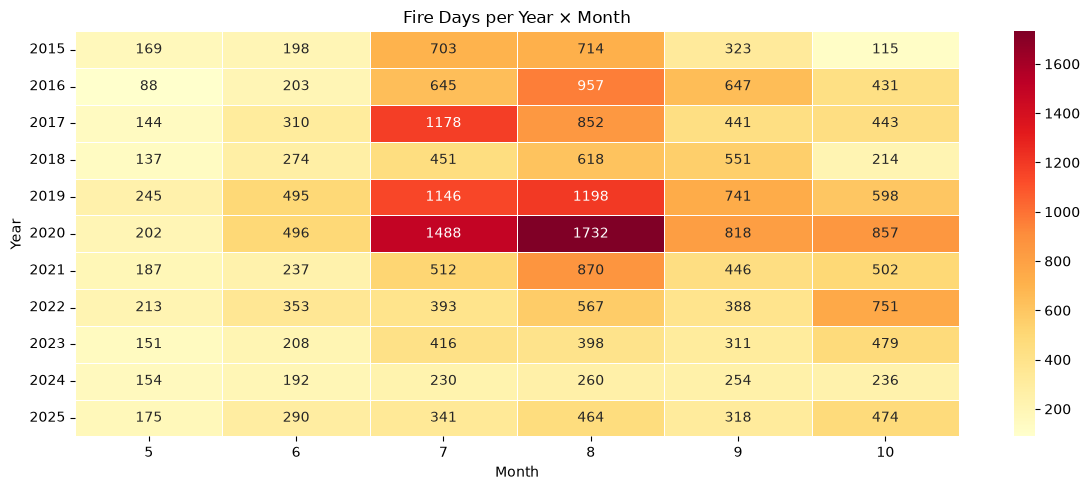

In [4]:
print("Temporal coverage by year:")
yearly = df.groupby(df["date"].dt.year).agg(
    rows=("date", "count"),
    fire_days=("next_day_risk_class", lambda x: (x > 0).sum()),
    communes=("commune_id", "nunique"),
    positive_rate=("next_day_risk_class", lambda x: f"{100*(x>0).mean():.1f}%")
).reset_index()
yearly.columns = ["year", "rows", "fire_days", "communes", "positive_rate"]
print(yearly.to_string(index=False))

# Fire days per month across all years
monthly = df.groupby(["year", "month"])["next_day_risk_class"].apply(
    lambda x: (x > 0).sum()
).reset_index()
monthly.columns = ["year", "month", "fire_days"]

pivot = monthly.pivot(index="year", columns="month", values="fire_days").fillna(0)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.5, ax=ax)
ax.set_title("Fire Days per Year × Month")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.savefig("outputs/01_temporal_heatmap.png", dpi=150)
plt.show()

#### Spatial coverage

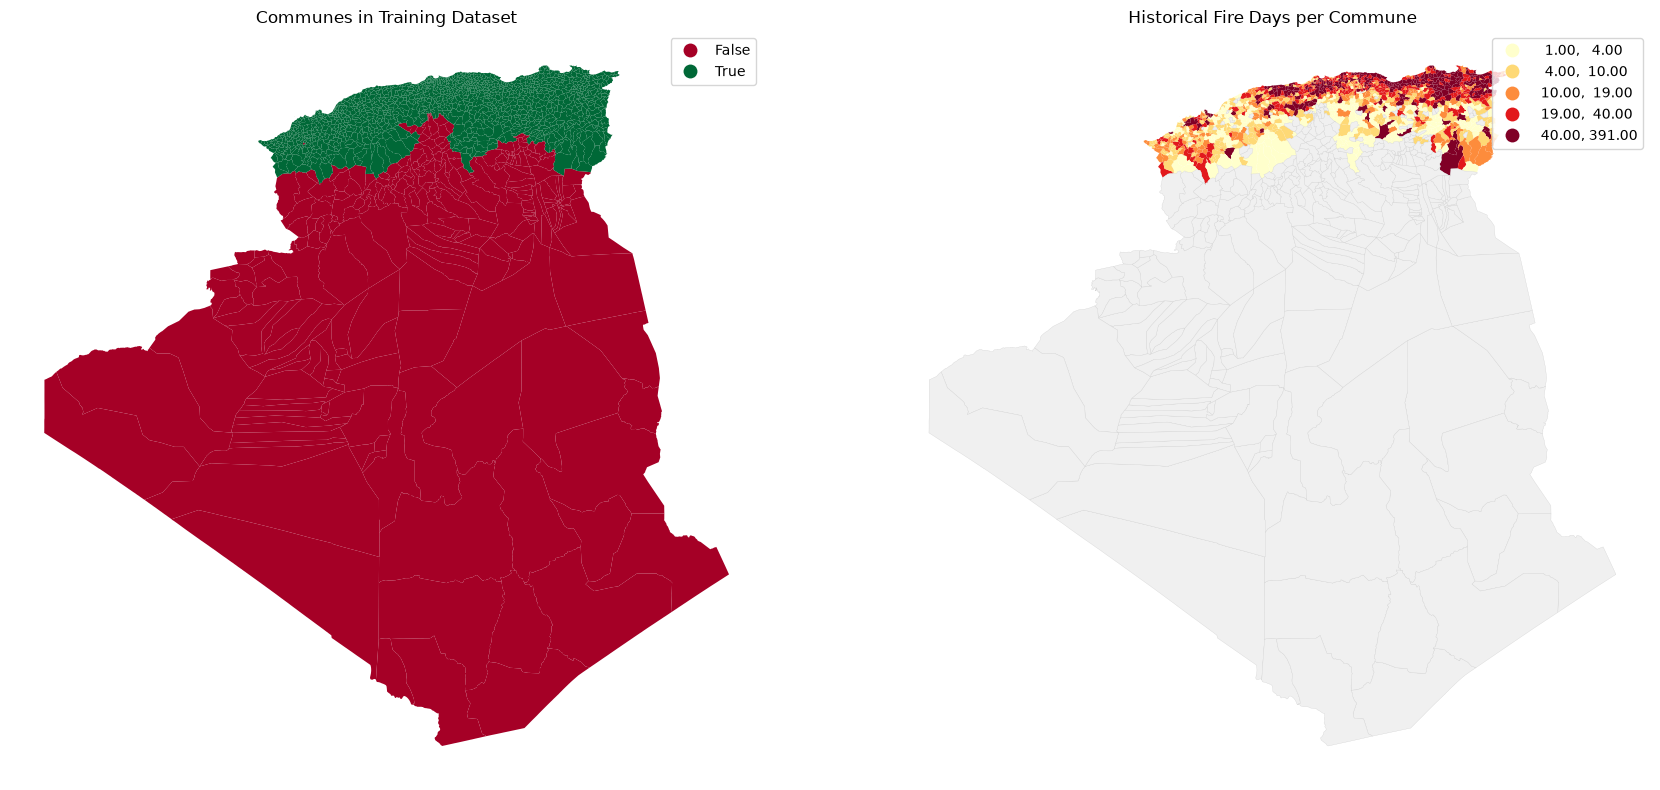

In [5]:
communes = gpd.read_file("../data/training/curated/boundaries/algeria_communes.gpkg")
communes = communes.rename(columns={"GID_2": "commune_id", "NAME_2": "commune_name",
                                     "GID_1": "wilaya_id", "NAME_1": "wilaya_name"})

fire_counts = (
    df[df["next_day_risk_class"] > 0]
    .groupby("commune_id")
    .size()
    .reset_index(name="fire_days")
)

communes_merged = communes.merge(fire_counts, on="commune_id", how="left")
communes_merged["fire_days"] = communes_merged["fire_days"].fillna(0)
communes_merged["in_dataset"] = communes_merged["commune_id"].isin(
    df["commune_id"].unique()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Which communes are in dataset
communes_merged.plot(
    column="in_dataset",
    categorical=True,
    ax=axes[0],
    cmap="RdYlGn",
    legend=True
)
axes[0].set_title("Communes in Training Dataset")
axes[0].axis("off")

# Fire frequency
communes_merged[communes_merged["fire_days"] > 0].plot(
    column="fire_days",
    ax=axes[1],
    cmap="YlOrRd",
    legend=True,
    scheme="quantiles",
    k=5
)
communes_merged[communes_merged["fire_days"] == 0].plot(
    ax=axes[1], color="#f0f0f0", edgecolor="#cccccc", linewidth=0.2
)
axes[1].set_title("Historical Fire Days per Commune")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("outputs/01_spatial_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

#### Feature group completness

In [6]:
feature_groups = {
    "Weather (ERA5)":    ["temp_c", "rh", "wind_speed_kmh", "wind_dir",
                          "precip_mm", "soil_moisture"],
    "FWI Indices":       ["FFMC", "DMC", "DC", "ISI", "BUI", "FWI"],
    "Vegetation":        ["NDVI", "NDWI", "NBR"],
    "Terrain":           ["elevation_mean_m", "slope_mean_deg", "aspect_mean_deg"],
    "Human":             ["pop_density_mean", "road_distance_mean_km"],
    "Land Cover":        ["forest_fraction", "shrub_fraction", "grass_fraction",
                          "crop_fraction", "burnable_fraction"],
    "Fire State":        ["fire_count", "mean_frp"],
}

print(f"{'Group':<20} {'Features':<8} {'Complete':<10} {'Missing'}")
print("─" * 60)
for group, cols in feature_groups.items():
    present = [c for c in cols if c in df.columns]
    missing_cols = [c for c in cols if c not in df.columns]
    if present:
        completeness = 100 * (1 - df[present].isnull().any(axis=1).mean())
    else:
        completeness = 0
    status = "NO Problem" if completeness == 100 and not missing_cols else "Warning"
    print(f"{status} {group:<18} {len(present)}/{len(cols):<6} "
          f"{completeness:.1f}%{'':5} "
          f"{missing_cols if missing_cols else ''}")

Group                Features Complete   Missing
────────────────────────────────────────────────────────────
NO Problem Weather (ERA5)     6/6      100.0%      
NO Problem FWI Indices        6/6      100.0%      
NO Problem Vegetation         3/3      100.0%      
NO Problem Terrain            3/3      100.0%      
NO Problem Human              2/2      100.0%      
NO Problem Land Cover         5/5      100.0%      
NO Problem Fire State         2/2      100.0%      


#### Feature/Target correlations

Feature correlation with next_day_risk_class:
mean_frp             0.255
temp_c               0.187
fire_count           0.187
FWI                  0.161
NDVI                 0.150
NBR                  0.138
burnable_fraction    0.137
BUI                  0.131
slope_mean_deg       0.129
FFMC                 0.129
ISI                  0.127
DMC                  0.123
rh                  -0.120
DC                   0.116
NDWI                 0.105
elevation_mean_m    -0.087
precip_mm           -0.085
wind_speed_kmh      -0.008


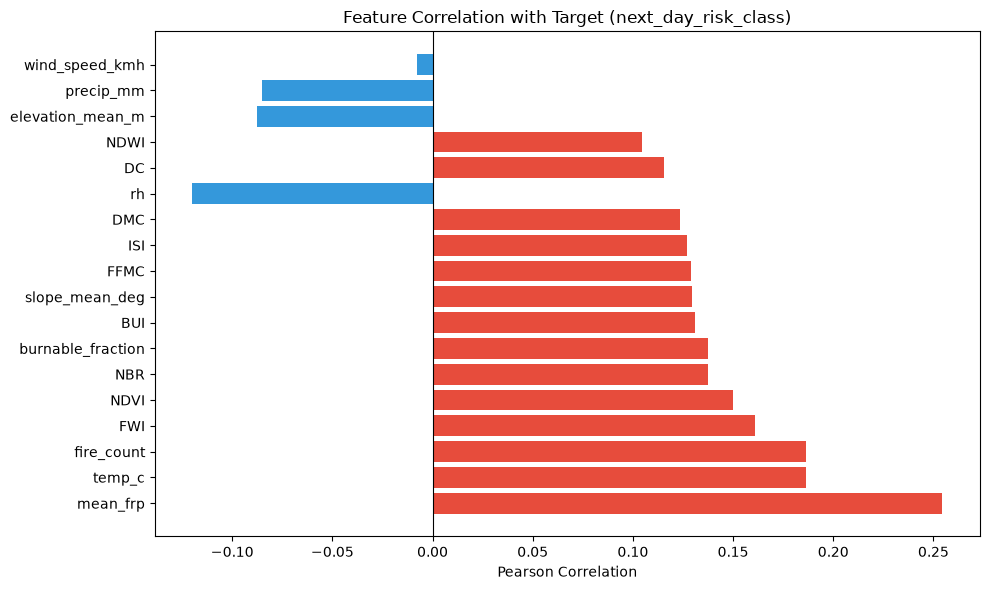

In [7]:
# ── Correlation of numeric features with target ────────────────────
numeric_cols = ["temp_c", "rh", "wind_speed_kmh", "precip_mm",
                "FFMC", "DMC", "DC", "ISI", "BUI", "FWI",
                "NDVI", "NDWI", "NBR", "elevation_mean_m",
                "slope_mean_deg", "burnable_fraction",
                "fire_count", "mean_frp"]
numeric_cols = [c for c in numeric_cols if c in df.columns]

correlations = df[numeric_cols + ["next_day_risk_class"]].corr()[
    "next_day_risk_class"
].drop("next_day_risk_class").sort_values(key=abs, ascending=False)

print("Feature correlation with next_day_risk_class:")
print(correlations.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c" if v > 0 else "#3498db" for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with Target (next_day_risk_class)")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.savefig("outputs/01_feature_correlations.png", dpi=150)
plt.show()

#### Leakage check

In [8]:
# Verify next_day_risk_class is genuinely next-day, not same-day
print("LEAKAGE CHECK")
print("─" * 55)

# Same-day fire vs next-day label correlation
# If same_day fire_count perfectly predicts next_day → possible leakage
from scipy.stats import pointbiserialr

same_day_fire = (df["fire_count"] > 0).astype(int)
next_day_fire = (df["next_day_risk_class"] > 0).astype(int)

corr, pval = pointbiserialr(same_day_fire, next_day_fire)
print(f"Same-day fire → next-day fire correlation: {corr:.3f} (p={pval:.2e})")
print(f"Expected: moderate (~0.3-0.5), not perfect (1.0)")
print(f"{'OK' if corr < 0.8 else 'SUSPICIOUSLY HIGH — possible leakage'}")

# Verify date shift is correct — spot check one commune
sample_commune = df["commune_id"].value_counts().index[0]
sample = df[df["commune_id"] == sample_commune].sort_values("date")[
    ["date", "fire_count", "next_day_fire_count", "next_day_risk_class"]
].head(10)
print(f"\nSpot check commune {sample_commune}:")
print(sample.to_string(index=False))
print("\nVerify: next_day_fire_count on row N == fire_count on row N+1")

LEAKAGE CHECK
───────────────────────────────────────────────────────
Same-day fire → next-day fire correlation: 0.364 (p=0.00e+00)
Expected: moderate (~0.3-0.5), not perfect (1.0)
OK

Spot check commune DZA.23.12_1:
      date  fire_count  next_day_fire_count  next_day_risk_class
2015-05-03           0                    1                    1
2015-05-08           0                    0                    0
2015-05-22           0                    1                    1
2015-06-16           0                    0                    0
2015-07-10           0                    1                    1
2015-07-13           0                    0                    0
2015-08-05           0                    1                    1
2015-08-06           1                    1                    1
2015-08-12           0                    3                    2
2015-08-20           0                    2                    1

Verify: next_day_fire_count on row N == fire_count on row N+1


#### Class balance by wilaya

Top 15 wilayas by positive rate:
next_day_risk_class   LOW  MODERATE  HIGH  positive_rate
wilaya_name                                             
Constantine          1267       788   216      44.209599
Jijel                2763      1225   765      41.868294
Blida                2426      1393   327      41.485769
Annaba               1192       637   192      41.019297
Skikda               3870      1719   646      37.931034
Oran                 2648      1247   154      34.601136
El Tarf              2332       607   421      30.595238
Béjaïa               4889      1273   784      29.614166
Alger                2663       872   106      26.860753
Khenchela            2188       613   176      26.503191
Boumerdès            3255       927   219      26.039536
Tipaza               2583       619   271      25.626260
Guelma               3541       768   303      23.222029
Aïn Defla            3665       756   347      23.133389
Tizi Ouzou           6698      1301   579      21.91653

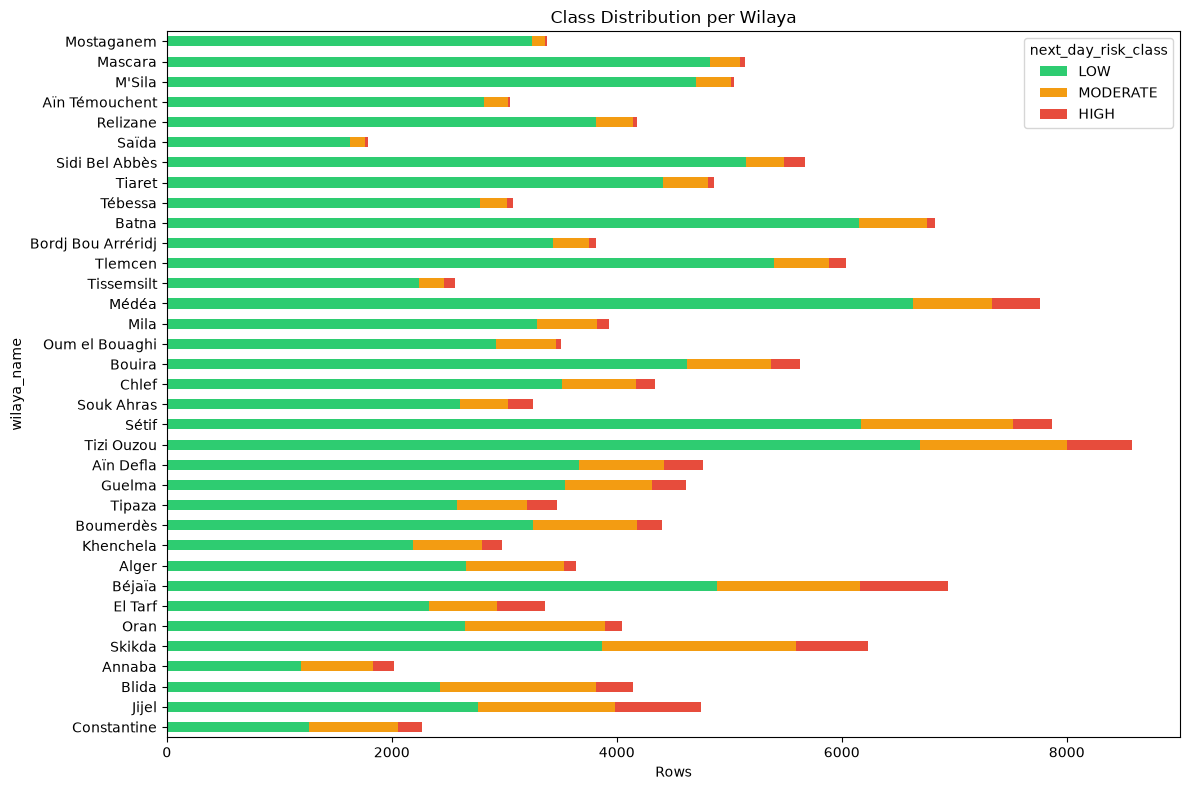

In [9]:
# ── Cell 8: Class balance per wilaya ──────────────────────────────────
wilaya_balance = (
    df.groupby(["wilaya_name", "next_day_risk_class"])
    .size()
    .unstack(fill_value=0)
    .rename(columns=RISK_LABELS)
)
wilaya_balance["total"] = wilaya_balance.sum(axis=1)
wilaya_balance["positive_rate"] = (
    100 * (wilaya_balance.get("MODERATE", 0) + wilaya_balance.get("HIGH", 0))
    / wilaya_balance["total"]
)
wilaya_balance = wilaya_balance.sort_values("positive_rate", ascending=False)

print("Top 15 wilayas by positive rate:")
print(wilaya_balance[["LOW", "MODERATE", "HIGH", "positive_rate"]].head(15).to_string())

fig, ax = plt.subplots(figsize=(12, 8))
wilaya_balance[["LOW", "MODERATE", "HIGH"]].plot(
    kind="barh", stacked=True, ax=ax,
    color=["#2ecc71", "#f39c12", "#e74c3c"]
)
ax.set_title("Class Distribution per Wilaya")
ax.set_xlabel("Rows")
plt.tight_layout()
plt.savefig("outputs/01_wilaya_balance.png", dpi=150)
plt.show()